## Notebook for Longhurst biomes/provinces analysis

In [1]:
import pandas as pd 
import geopandas as gpd
import shapefile
from shapely.geometry import Point, MultiPolygon
from shapely.geometry import shape
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.simplefilter('ignore')

### How far has SeaFlow been around the world?

In [3]:
from geopy.distance import geodesic
from geopy.distance import great_circle 
# helper function to calculate distance traveled per cruise
def km_traveled(cruise):
    # create a list to store the distances
    distances = []
    # loop through the rows and calculate the distance between each row
    for i in range(len(cruise)-1):
        # get the lat and lon for the current row and the next row
        lat1 = cruise.iloc[i]['lat']
        lon1 = cruise.iloc[i]['lon']
        lat2 = cruise.iloc[i+1]['lat']
        lon2 = cruise.iloc[i+1]['lon']
        # calculate the distance between the two points
        coords_1 = (lat1, lon1)
        coords_2 = (lat2, lon2)
        distance = geodesic(coords_1, coords_2).km
        # append the distance to the list
        distances.append(distance)
    # sum distances to get total distance traveled
    return distances

In [4]:
hourly_sf = pd.read_pickle('../data/hourly_sf_v1_all.pickle')
cruise_distances = []
# set lon to prevent complications with international date line
hourly_sf['lon']=np.where(hourly_sf['lon']>0, hourly_sf['lon'], hourly_sf['lon']+360)
# get the cruise names
names = pd.unique(hourly_sf['cruise'])
for cruise in names:
    # get subdf of cruise
    sub_df=hourly_sf.loc[hourly_sf['cruise']==cruise]
    # first sort by time
    sub_df = sub_df.sort_values(by='time')
    # calculate distance traveled
    distance_traveled=km_traveled(sub_df)
    # print cruise and distance traveled
    # print(cruise)
    # print(np.sum(distance_traveled))
    # save distance traveled in list
    cruise_distances.append(distance_traveled)

# calculate sum of distances for each cruise
np.sum([np.sum(cruise) for cruise in cruise_distances])

167548.4203260462

### How many unique days were successfuly run by TSD??


In [5]:
# total from successful productivity results
all_tsd = pd.read_pickle('../data/all_seaflow_tsd_mixed_v1_all.pickle')
tsd_days = len(all_tsd.groupby(['cruise','cruise_day']).count())

print(f'TSD successfully ran for {tsd_days} days')

TSD successfully ran for 767 days


### Use longhurst provinces to cluster TSD-PP results

In [ ]:
# read in data
final_rates = pd.read_pickle('../data/final_rates_v1_all.pickle')
# set lon range between -180 to 180
final_rates['lon'] = np.where(final_rates['lon']>180, final_rates['lon']-360, final_rates['lon'])

lh_shapefile = '../data/shapefiles/Longhurst_world_v4_2010/Longhurst_world_v4_2010.shp'
gfinal_rates = gpd.read_file(lh_shapefile)
gfinal_rates['biome'] = gfinal_rates['ProvDescr'].str.split().str[0]

# Convert dataframe to a GeoDataFrame
final_rates['geometry'] = final_rates.apply(lambda row: Point(row['lon'], row['lat']), axis=1)
final_rates_geo = gpd.GeoDataFrame(final_rates, geometry='geometry', crs=gfinal_rates.crs)

# Perform spatial join to get region information
final_rates_geo = gpd.sjoin(final_rates_geo, gfinal_rates[['geometry', 'ProvCode', 'biome']], how='left', predicate='within')

final_rates_geo.rename(columns={'ProvCode': 'region'}, inplace=True)
# columns with nan are in the sound (ccal)
final_rates_geo.loc[final_rates_geo['region'].isna(), 'region'] = 'CCAL'

# Save the updated dataframe
final_rates_geo.drop(columns=['geometry', 'index_right'], inplace=True)

In [16]:
# read in model failed reaults
combined_fails=pd.read_pickle('../data/combined_fails.pickle').drop_duplicates(['cruise','cruise_day','pop'])
mean_tsd=all_tsd.groupby(['cruise','cruise_day'])[['lat','lon']].mean().reset_index()
## do some cleaning
good_rates=final_rates.copy()
# fix time
good_rates['time']=pd.DatetimeIndex(good_rates['time']).tz_localize('UTC')
# fix longitude
combined_fails['lon']=np.where(combined_fails['lon']>0, combined_fails['lon'], combined_fails['lon']+360)
good_rates['lon']=np.where(good_rates['lon']>0, good_rates['lon'], good_rates['lon']+360)
# add depth col
good_rates['depth']=5

# only get failure rates that aren't also a success
## for cases in which 1 model fails but another passes
fails_only=combined_fails.drop(columns=['model']).merge(good_rates, how='outer',indicator=True)
fails_only=fails_only.loc[fails_only['_merge']=='left_only'][['cruise','cruise_day',
                                                              'pop','lat','lon','fail_reason']]
fails_only['status']='fail'

In [17]:
# combine rates together
combined_rates=good_rates.merge(fails_only, how='outer', indicator=True)

combined_rates.loc[combined_rates['status'].isnull(), 'status']='success'
## try binning every 5 degree
combined_rates['round_lat']=(5 * round(combined_rates['lat']/5)).astype(int)
combined_rates['round_lon']=(5 * round(combined_rates['lon']/5)).astype(int)
# changed failed rows pop to "failed"
combined_rates.loc[combined_rates['status']=='fail','pop']='failed'


## remove days with any failed pops (productivity map) and adjust for too large vals
combined_rates.loc[combined_rates['productivity']>20,'productivity']=np.nan

In [31]:
from matplotlib.patches import Circle
from matplotlib.legend_handler import HandlerPatch
import matplotlib.patches as mpatches

# Custom handler that draws circles in the legend with correct relative sizes
class HandlerCircle(HandlerPatch):
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        # Get radius from the original handle
        r = orig_handle.get_radius()
        # Create a circle centered in the handlebox
        center = (0.5 * width - 0.5 * xdescent, 0.5 * height - 0.5 * ydescent)
        p = mpatches.Circle(center, r)
        self.update_prop(p, orig_handle, legend)
        p.set_transform(trans)
        return [p]

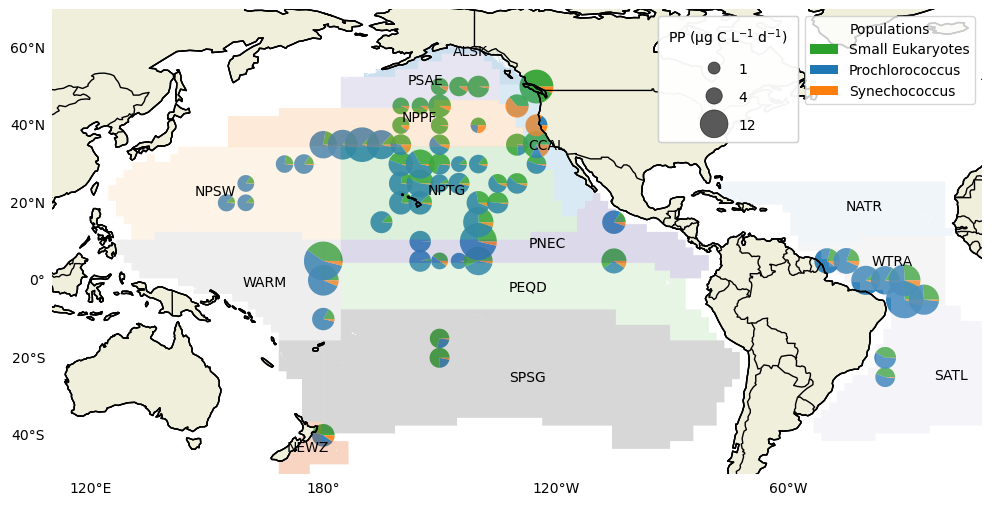

In [63]:
# save regions
regions = pd.unique(final_rates_geo['region'])

# helper function to draw pie chart on map
def plot_pie_direct(dataframe_pie,ilat_pie,ilon_pie,pop_colors,axis_main,
                    width_local,alpha_local,make_legend=False):
    # make wedges and text
    wedges,texts= ax_main.pie(dataframe_pie,colors=pop_colors,radius=width_local)
    # check if make legend
    if make_legend:
        labels=['Small Eukaryotes', 'Prochlorococcus', 'Synechococcus']
        l1 = plt.legend(wedges, labels, loc="best", title='Populations')
        ax_main.add_artist(l1)
    # adjust each wedge
    for w in wedges:
        w.set_linewidth(0.02)  ## Reduce linewidth to near-zero
        w.transform=ccrs.PlateCarree(central_longitude=180)
        # offset by 180
        w.set_center((ilon_pie-180,ilat_pie))
        w.set_zorder(0)
        w.set_alpha(alpha_local)

# make color map by population
cmap={'prochloro':'#1f77b4', 'synecho':'#ff7f0e', 'picoeuk':'#2ca02c', 
             'failed':'tab:gray'}
fig= plt.figure(figsize=(12,20))
# Define both CRS objects explicitly
data_crs = ccrs.PlateCarree()  # standard geographic CRS (central_longitude=0)
map_proj = ccrs.PlateCarree(central_longitude=180)

# After creating the axes and setting extent:
ax_main = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax_main.set_extent([110, 350, -50, 70], crs=ccrs.PlateCarree())
# Turn off autoscaling so pie wedges don't expand the view
ax_main.set_autoscale_on(False)

# remove gridlines
gl=ax_main.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.xlines=None
gl.ylines=None

ax_main.coastlines(zorder=3)
# Plot selected Longhurst provinces
gdf = gfinal_rates.loc[gfinal_rates['ProvCode'].isin(regions)]
prov = gdf.plot(ax=ax_main, column='ProvCode', cmap='tab20c', alpha=0.25, legend=True, 
         transform =ccrs.PlateCarree())
# add region name to each province
# Add province labels at the centroid of each polygon
for idx, row in gdf.iterrows():
    # check if multipolygon first
    if isinstance(row.geometry, MultiPolygon):
        # Better for MultiPolygon
        centroid = row.geometry.representative_point()
    else:
        centroid = row.geometry.centroid
    # manually shift if ALSK to prevent label from being obscured
    if row['ProvCode']=='ALSK':
        ax_main.text(centroid.x+15, centroid.y+2, row['ProvCode'], fontsize=10, ha='center', 
                 transform=ccrs.PlateCarree())
    else:
        ax_main.text(centroid.x, centroid.y, row['ProvCode'], fontsize=10, ha='center', 
                 transform=ccrs.PlateCarree())

## remove days with any failed pops (productivity map) and adjust for too large vals
combined_rates.loc[combined_rates['productivity']>20,'productivity']=np.nan
### for productivity map
combined_group=combined_rates[['cruise','cruise_day','pop',
                               'round_lat', 'round_lon', 'productivity']].groupby(['cruise','cruise_day','pop']).mean()

# get rid of rows with a cruise day that has failed population type
sub_dfs=[]
for cruise, new_df in combined_group.groupby(level=[0,1]):
    # check if failed population is present in a cruise day OR if productivity is nan
    if ('failed' not in (list(pd.unique(new_df.reset_index()['pop']))))&(~new_df['productivity'].isna().any()):
        # if not present AND no nulls, append
        sub_dfs.append(new_df)
# save final df
final_groups=pd.concat(sub_dfs).reset_index()
# group by lat/lon
combined_final=final_groups.groupby(['round_lat','round_lon','pop']).agg(({
    'productivity':'mean'
}))
# calculate percent
combined_final['percent']=combined_final.groupby(level=[0,1]).apply(
     lambda x: x/ x.sum())['productivity'].values
# calculate scaling
obs_list=combined_final.groupby(level=[0,1]).sum()['productivity'].values
# rescale from 1.5-6
interval_min = 2
interval_max = 5
# scale observations from custom list
scaled_obs=((((obs_list-np.min(obs_list))/(np.max(obs_list)-np.min(obs_list)))*
 (interval_max-interval_min))+interval_min)


# loop thru each df and plot
counter=0
legend=False
for i, df in combined_final.groupby(level=[0,1]):
    # get data needed to make piechart
    lat, lon=i
    percents=df.percent.values
    # get colors
    pops=df.index.get_level_values(2).values
    colors=[cmap[key] for key in pops]
    # get scaled number for width
    obs=scaled_obs[counter]
    # make legend once
    if (len(pops)==3)&(legend==False):
        plot_pie_direct(percents, lat, lon, colors,ax_main, obs, 0.9, make_legend=True)
        legend=True
    # make piechart
    else:
        plot_pie_direct(percents, lat, lon, colors,ax_main, obs, 0.9)
    counter+=1


# PP values to include in legend
pp_values = [1, 4, 12]
# Scale PP values using the SAME scaling as your pie chart radii
obs_min = np.min(obs_list)
obs_max = np.max(obs_list)
interval_min = 2
interval_max = 5
# scale custom radii
scaled_legend = [((( (pp - obs_min) / (obs_max - obs_min)) *
                   (interval_max - interval_min)) + interval_min) for pp in pp_values]
# Normalize to a reasonable legend icon size (scale down for the handlebox)
max_scaled = max(scaled_legend)
legend_circles = []
for pp, sc in zip(pp_values, scaled_legend):
    # Scale radius relative to handlebox (~5-12 pts)
    r = (sc / max_scaled) * 10
    c = Circle((0, 0), radius=r, facecolor='k', edgecolor='black',
               linewidth=0.5, alpha=0.6)
    legend_circles.append(c)
# create legend labels
legend_labels = [str(pp) for pp in pp_values]
# Create the size legend
leg2 = ax_main.legend(
    legend_circles, legend_labels,
    handler_map={Circle: HandlerCircle()},
    title='PP (µg C L$^{-1}$ d$^{-1})$',
    loc='upper right',
    bbox_to_anchor=(0.81, 1.0),   # adjust to place LEFT of the population legend
    frameon=True,
    labelspacing=1,             # vertical spacing between entries
    handletextpad=0.75,
    borderpad=0.75,               # more padding between entries and legend border edge
    borderaxespad=0.5
)
# Add it back so it doesn't replace the first (population) legend
ax_main.add_artist(leg2)

# add features
ax_main.coastlines(zorder=3)
ax_main.add_feature(cfeature.COASTLINE)
ax_main.add_feature(cfeature.LAND)
ax_main.add_feature(cfeature.BORDERS)
# set map extent 
ax_main.set_extent([110, 350, -50, 70], crs=ccrs.PlateCarree())

plt.show()

### Fig 1B

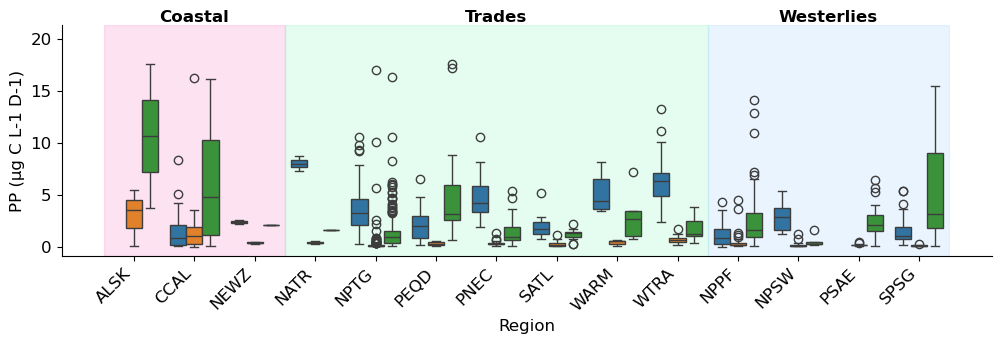

In [9]:
import matplotlib.patches as mpatches

# set order by region
regions_df = final_rates_geo.drop_duplicates(subset=['region']).reset_index().sort_values(by=['biome', 'region'])[['region', 'biome']]
ordered = list(regions_df['region'].values)


fig, ax = plt.subplots(figsize=(12, 3))
sns.boxplot(
    data=final_rates_geo,
    x='region',
    y='productivity',
    hue='pop',
    order=ordered,
    ax=ax,
    legend=False
)
sns.despine(ax=ax) 
plt.ylabel('PP (µg C L-1 D-1)', fontsize=12)
plt.xlabel('Region', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize = 12)

# highlight biomes
biome_colors = {
    'Coastal': "#F86FC1",
    'Westerlies': '#99CCFF',
    'Trades': "#79F5B7"
}
bio_blocks = []
start_idx = 0
current_biome = None

# loop through adn figure out starting index for each biome
for i, (region, biome) in enumerate(zip(regions_df['region'], regions_df['biome'])):
    if i == 0:
        current_biome = biome
        start_idx = i
    else:
        if biome != current_biome:
            bio_blocks.append((current_biome, start_idx, i-1))
            current_biome = biome
            start_idx = i
bio_blocks.append((current_biome, start_idx, i))

# hig
for biome, start, end in bio_blocks:
    ax.axvspan(start - 0.5, end + 0.5, color=biome_colors[biome], alpha=0.2)
    # Place the text label for the biome above the plotted region
    x_center = (start + end) / 2
    y_top = ax.get_ylim()[1]
    ax.text(
        x_center, y_top + 0.15 * (y_top - ax.get_ylim()[0]),  # Adjust the 0.1 as needed to ensure the label is outside the plotted data
        biome,
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )
# Optionally, increase the y-axis upper limit to ensure space for labels
ax.set_ylim(top=y_top + 0.15 * (y_top - ax.get_ylim()[0]))

plt.show()